In [79]:
# ===============================
# Path setup + autoreload
# ===============================

import sys
from pathlib import Path
import scanpy as sc
import pandas as pd

# Project root: C:\Users\user\Desktop\multiomic_vae
PROJECT_ROOT = Path(r"C:\Users\user\Desktop\multiomic_vae")

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Define important directories
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = PROJECT_ROOT / "processed_data"

# Jupyter autoreload (VERY IMPORTANT)
%load_ext autoreload
%autoreload 2

sc.set_figure_params(dpi=80, dpi_save=80, frameon=True, facecolor='white', figsize=(5,4))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1) Preprocessing Cell * Gene

In [80]:
# ===============================
# Load raw scRNA-seq data
# ===============================

from multiomic_vae.data.preprocess_rna import load_cell_gene

# Path to raw RNA data
rna_path = DATA_DIR / "pbmc_10k" / "10k_PBMC_Multiome_nextgem_Chromium_X_filtered_feature_bc_matrix.h5"

# Load cell × gene matrix
adata_rna = load_cell_gene(rna_path)

# Make gene names unique
adata_rna.var_names_make_unique()

# Add sample label (used later for QC and batch-aware steps)
adata_rna.obs["sample"] = "s1d1"

adata_rna

C:\Users\user\anaconda3\envs\peakvi\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
C:\Users\user\anaconda3\envs\peakvi\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 10970 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

### 1.1) Quality control (QC): annotation, visualization, and filtering
Mitochondrial, Ribosomal, and Hemoglobin genes were annotated and used to filter low-quality cells.

In [81]:
# ===============================
# QC annotation and metrics
# ===============================

from multiomic_vae.data.preprocess_rna import annotate_qc, compute_qc_metrics

# Annotate genes for QC (mitochondrial, ribosomal, hemoglobin)
adata_rna = annotate_qc(adata_rna)

# Compute QC metrics per cell using annotated gene groups
adata_rna = compute_qc_metrics(adata_rna)

adata_rna.obs.head()

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
AAACAGCCAACAACAA-1,s1d1,1579,7.365180,2890.0,7.969358,26.193772,33.287197,43.148789,62.664360,428.0,6.061457,14.809689,130.0,4.875197,4.498270,0.0,0.0,0.0
AAACAGCCACCGGCTA-1,s1d1,1368,7.221836,2373.0,7.772332,24.399494,32.827644,43.784239,63.421829,178.0,5.187386,7.501054,210.0,5.351858,8.849558,0.0,0.0,0.0
AAACAGCCAGGACACA-1,s1d1,728,6.591674,1116.0,7.018402,29.838710,38.799283,52.688172,79.569892,119.0,4.787492,10.663082,62.0,4.143135,5.555556,0.0,0.0,0.0
AAACAGCCATCCTAGA-1,s1d1,2068,7.634821,4518.0,8.416046,23.926516,31.451970,41.832669,60.026560,492.0,6.200509,10.889774,396.0,5.983936,8.764940,0.0,0.0,0.0
AAACATGCAAAGGTAC-1,s1d1,1813,7.503290,3841.0,8.253748,25.331945,33.142411,43.269982,62.171310,385.0,5.955837,10.023432,147.0,4.997212,3.827128,0.0,0.0,0.0


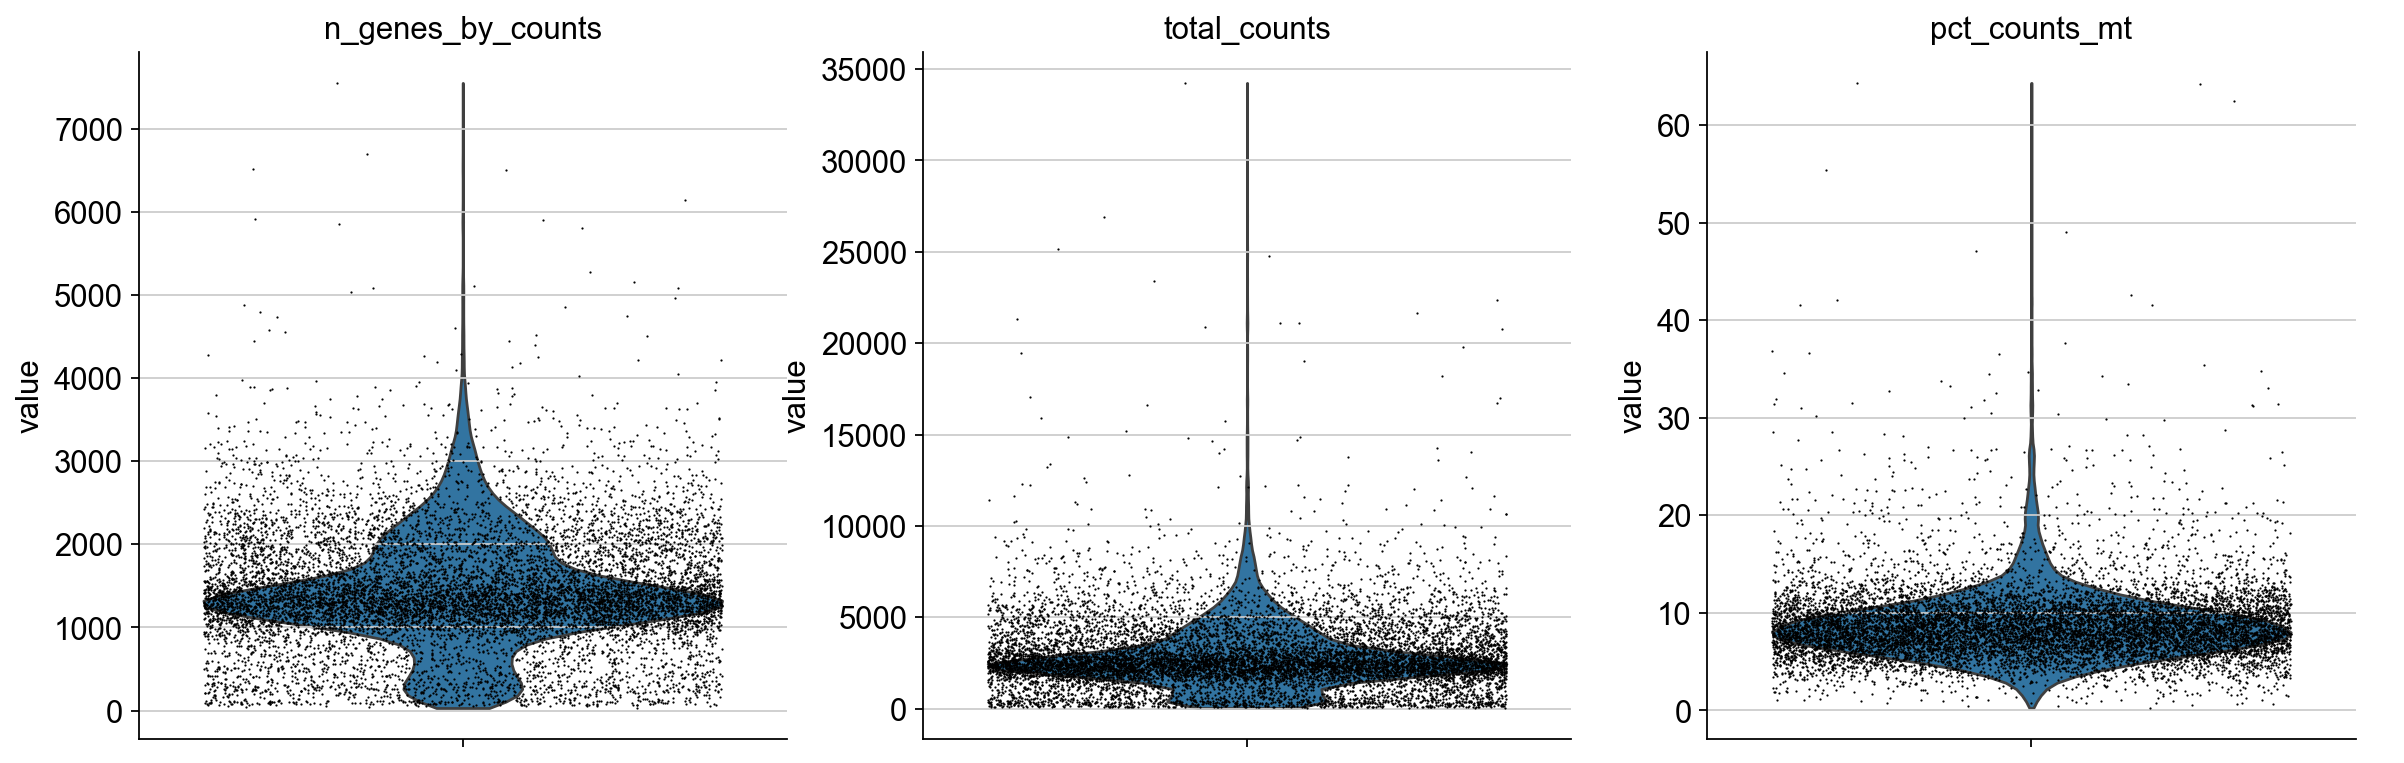

In [82]:
# ===============================
# QC visualization: mitochondrial genes
# ===============================

sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

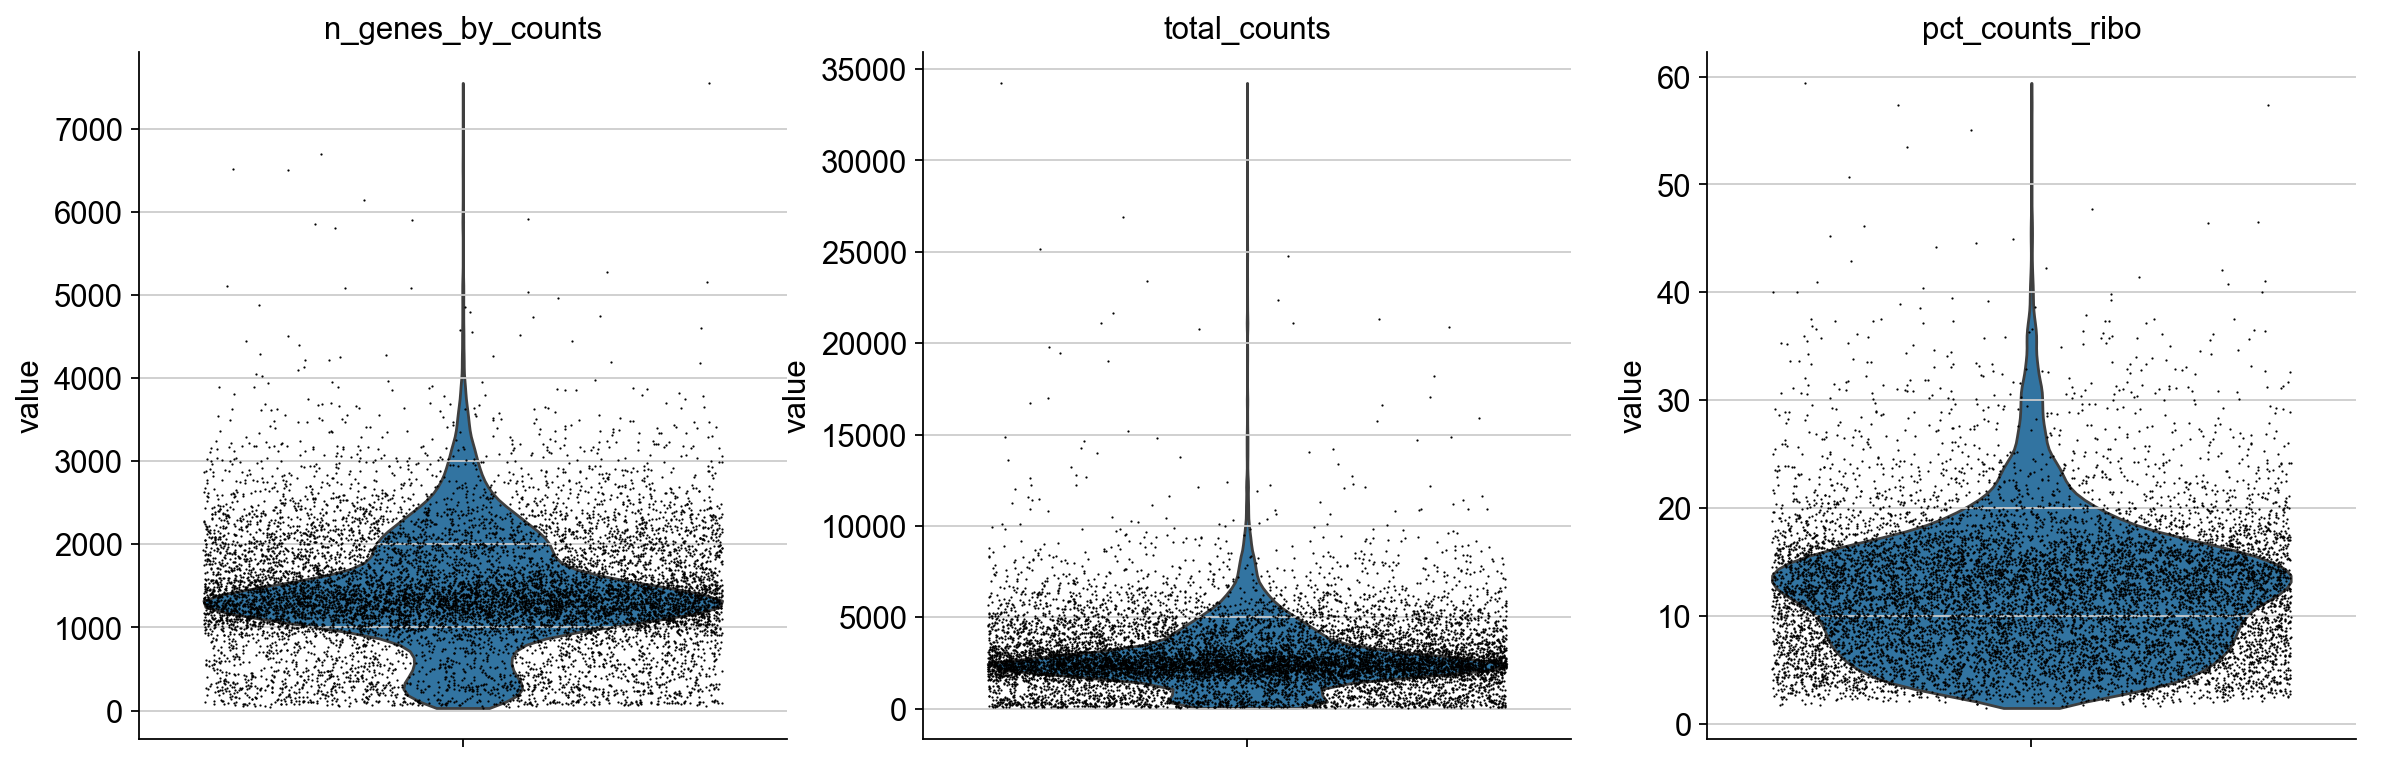

In [83]:
# ===============================
# QC visualization: ribosomal genes
# ===============================

sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True
)

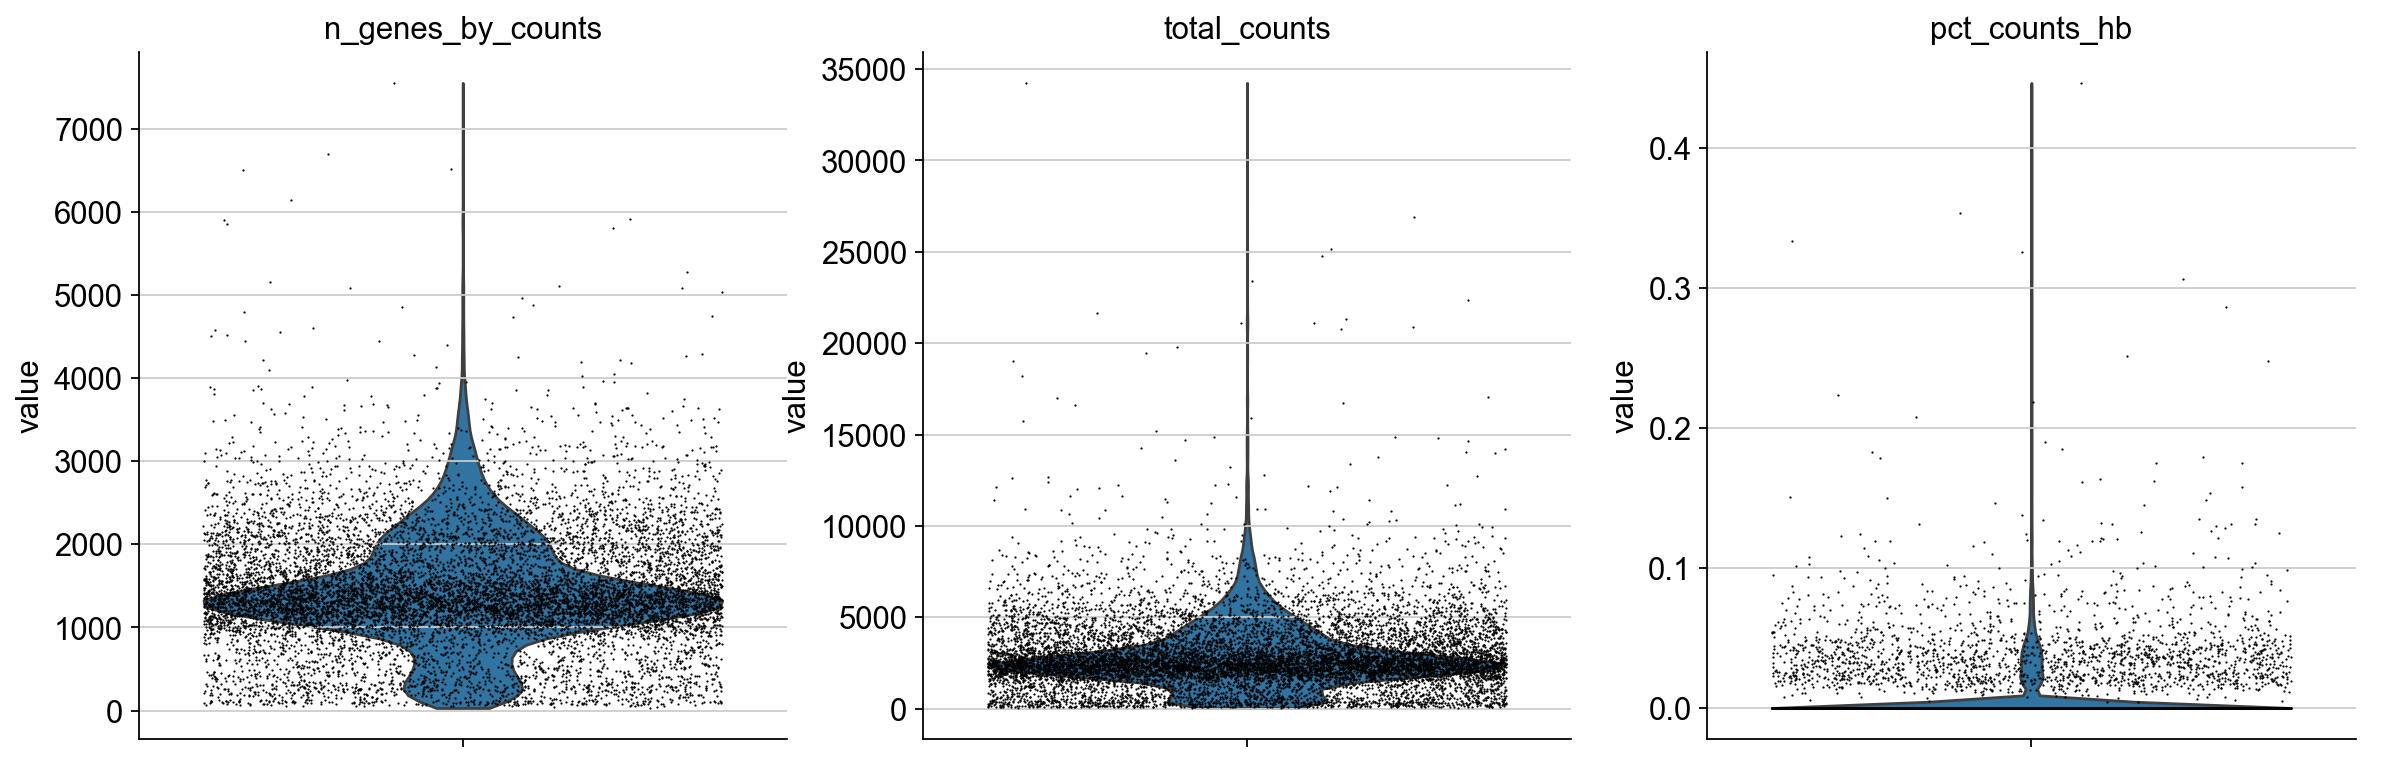

In [84]:
# ===============================
# QC visualization: hemoglobin genes
# ===============================

sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True
)

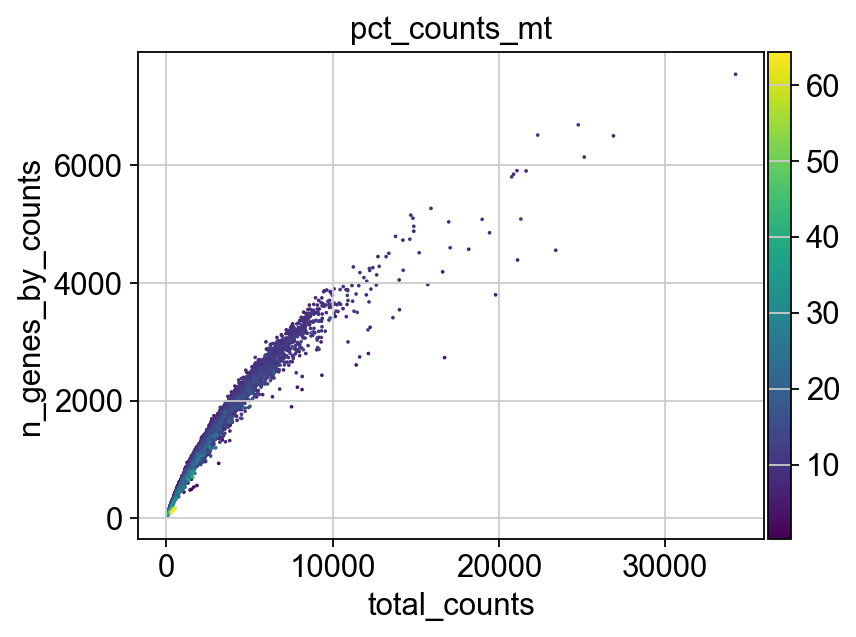

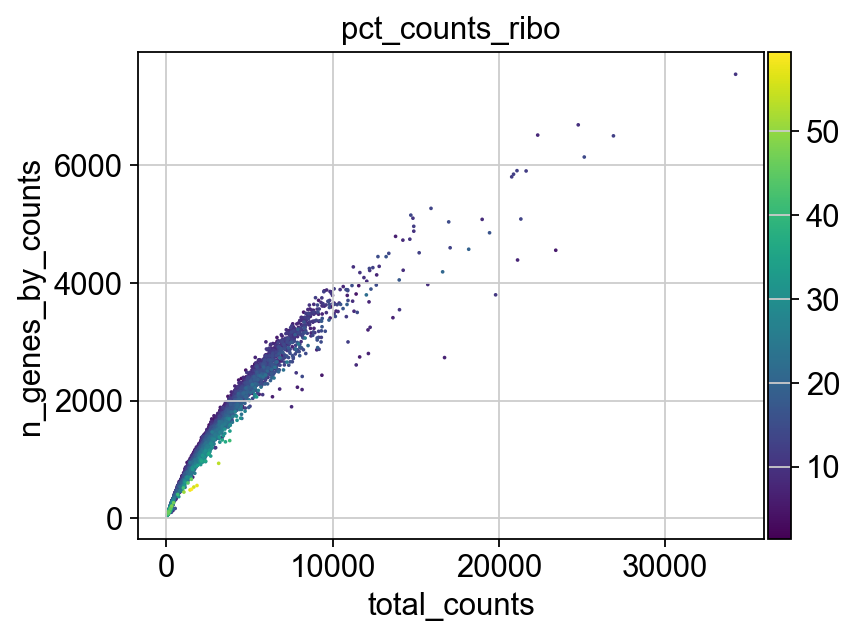

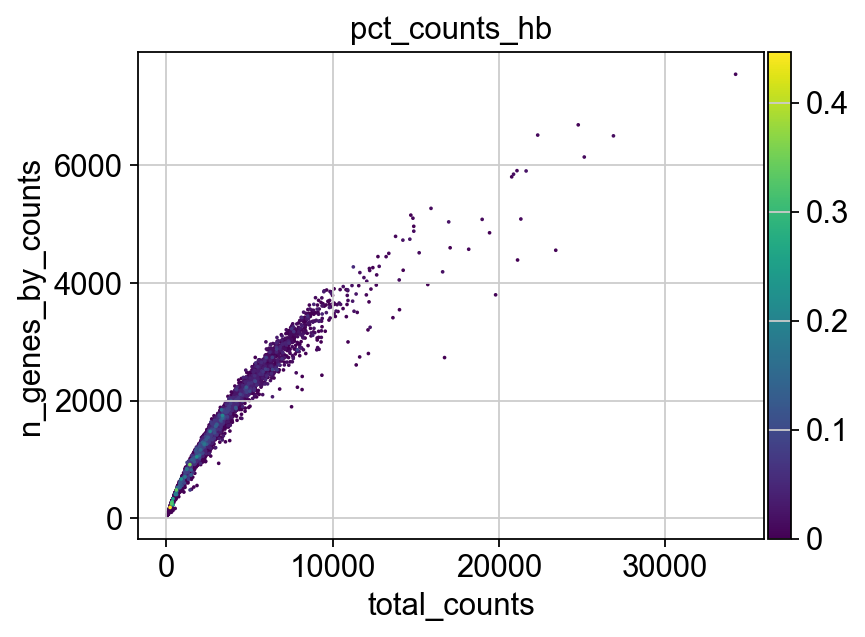

In [85]:
# ============================================
# QC scatter plots: total counts vs genes before filtering
# colored by mitochondrial / ribosomal / HB %
# ============================================

qc_metrics = [
    "pct_counts_mt",
    "pct_counts_ribo",
    "pct_counts_hb",
]

for qc in qc_metrics:
    sc.pl.scatter(
        adata_rna,
        x="total_counts",
        y="n_genes_by_counts",
        color=qc,
        title=qc,
        show=True
    )

In [86]:
# ===============================
# QC-based cell filtering
# ===============================

from multiomic_vae.data.preprocess_rna import filter_cells_by_qc

adata_rna = filter_cells_by_qc(
    adata_rna,
    max_mt_pct= 15,
    max_ribo_pct= 25,
    max_hb_pct=None
)

adata_rna

AnnData object with n_obs × n_vars = 10157 × 36601
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

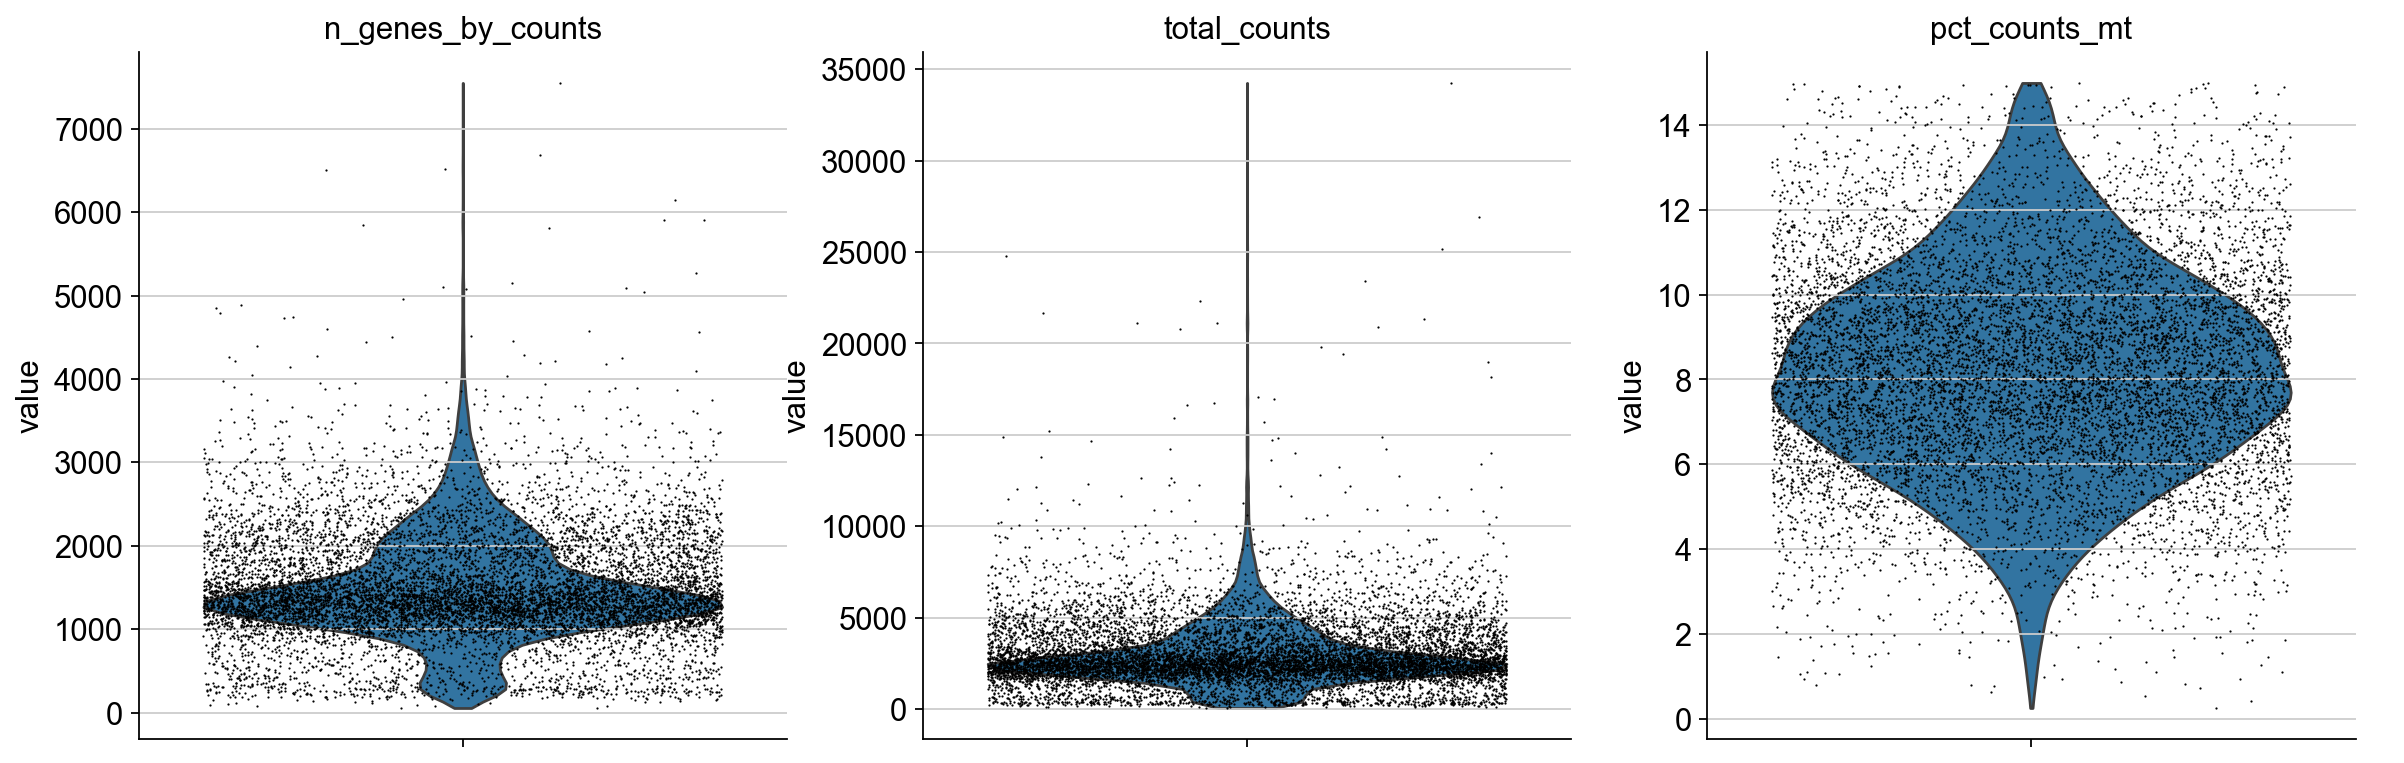

In [87]:
# ===============================
# QC visualization: mitochondrial genes after filtering
# ===============================

sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

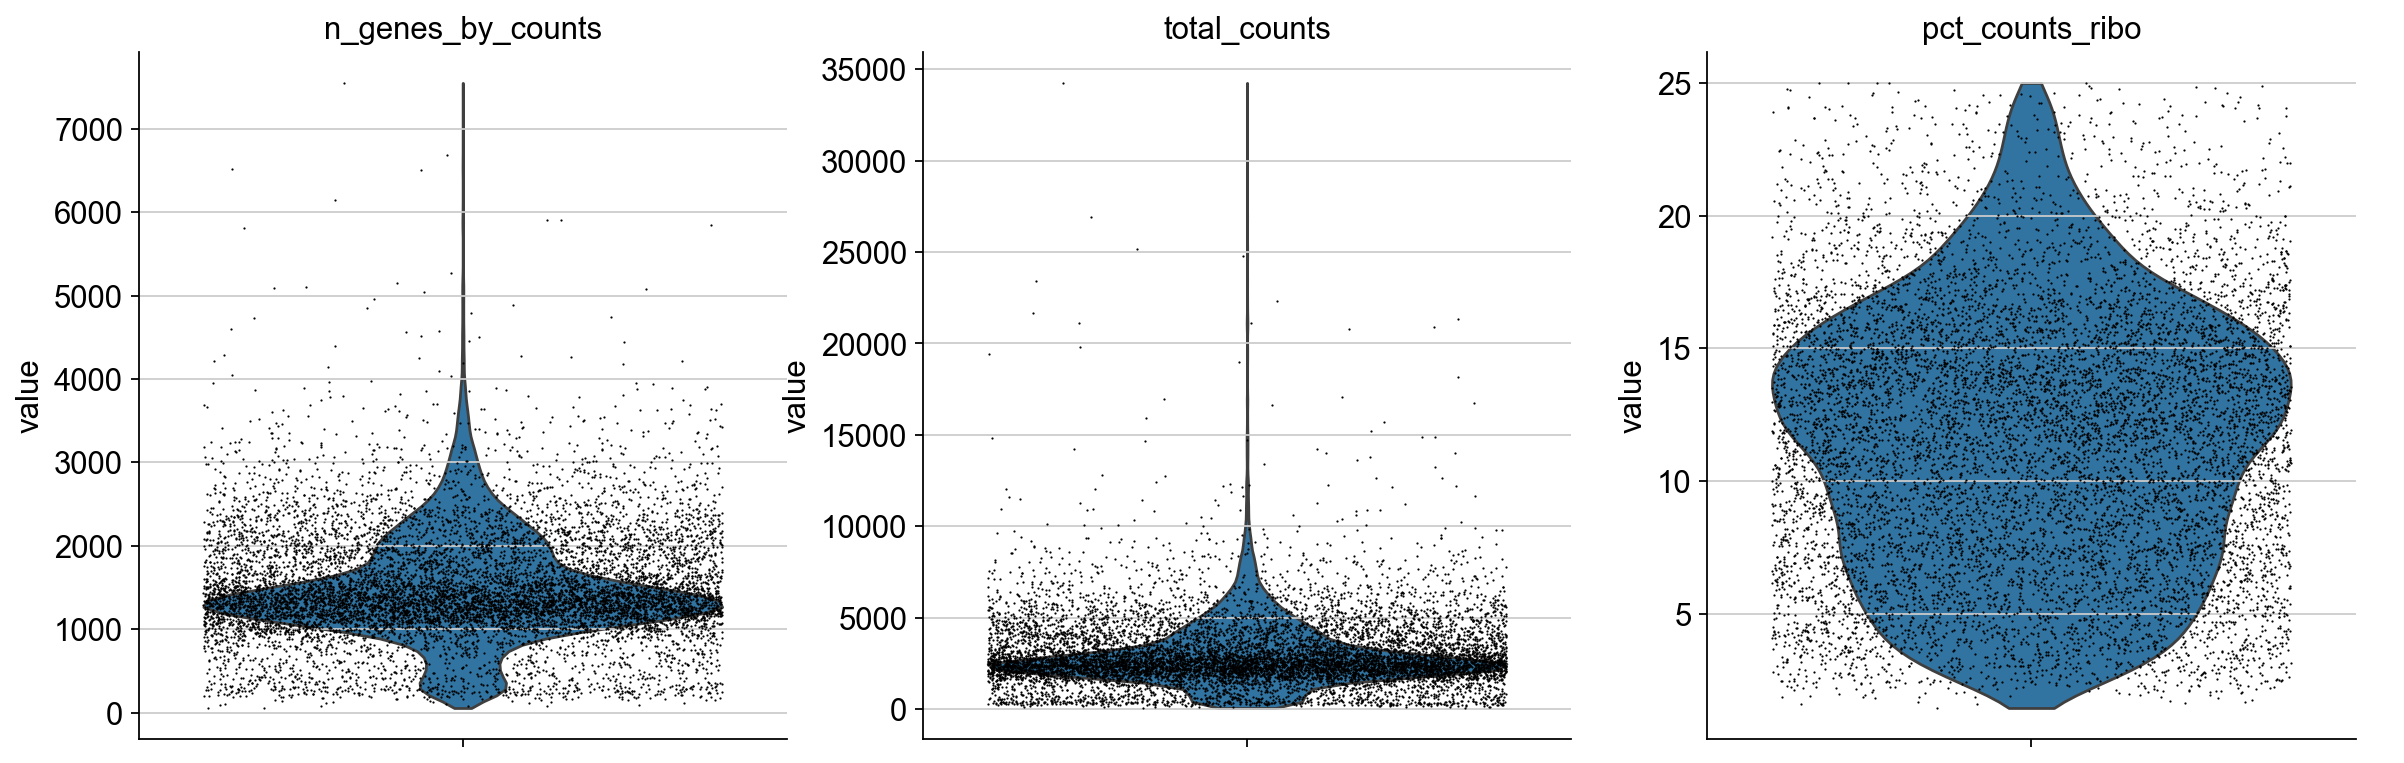

In [88]:
# ===============================
# QC visualization: ribosomal genes after filtering
# ===============================

sc.pl.violin(
    adata_rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True
)

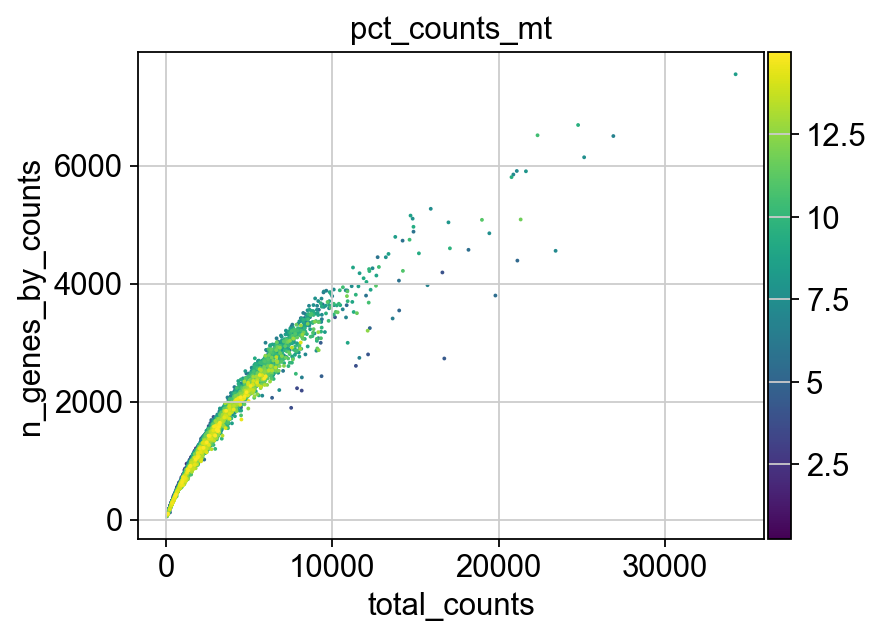

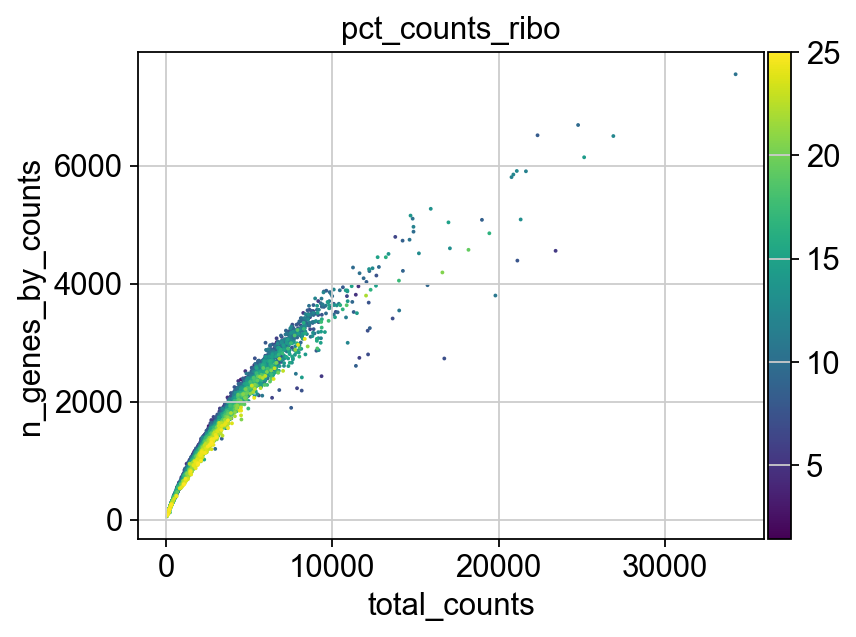

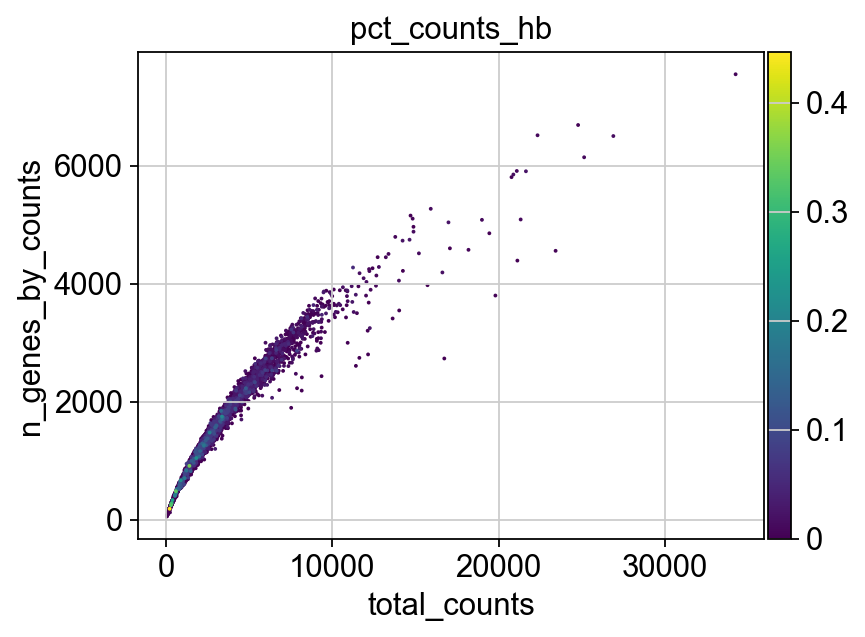

In [89]:
# ============================================
# QC scatter plots: total counts vs genes after filtering
# colored by mitochondrial / ribosomal / HB %
# ============================================

qc_metrics = [
    "pct_counts_mt",
    "pct_counts_ribo",
    "pct_counts_hb",
]

for qc in qc_metrics:
    sc.pl.scatter(
        adata_rna,
        x="total_counts",
        y="n_genes_by_counts",
        color=qc,
        title=qc,
        show=True
    )

### 1.2) Cell- and gene-level filtering

In [90]:
# ===============================
# Filter low-quality cells and genes
# ===============================

from multiomic_vae.data.preprocess_rna import filter_cells_genes

adata_rna = filter_cells_genes(
    adata_rna,
    min_genes=100,
    min_cells=3
)

adata_rna

AnnData object with n_obs × n_vars = 10150 × 25545
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

### 1.3) Doublet Detection

In [91]:
# ===============================
# Doublet detection
# ===============================

from multiomic_vae.data.preprocess_rna import detect_doublets

adata_rna = detect_doublets(adata_rna)

adata_rna.obs[["predicted_doublet", "doublet_score"]].head()


,predicted_doublet,doublet_score
AAACAGCCAACAACAA-1,True,0.219589
AAACAGCCACCGGCTA-1,False,0.017806
AAACAGCCAGGACACA-1,False,0.034024
AAACAGCCATCCTAGA-1,False,0.034024
AAACATGCAAAGGTAC-1,False,0.016873


### 1.4) Log1p noramlization of counts

In [92]:
# ============================================
# Normalize RNA data (counts → log1p)
# ============================================

from multiomic_vae.data.preprocess_rna import normalize_log1p

adata_rna = normalize_log1p(adata_rna)


### 1.5) HVGs selection

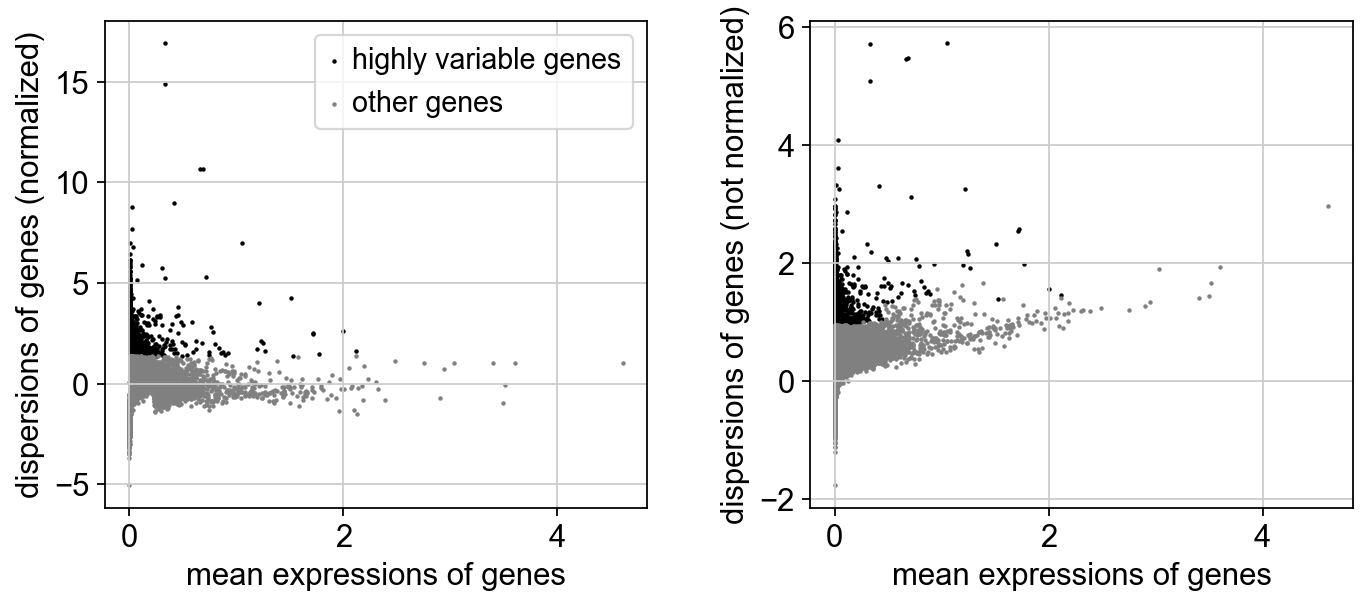

In [93]:
# ============================================
# Select highly variable genes (HVGs)
# - tag top variable genes per sample
# - no filtering applied yet
# ============================================

from multiomic_vae.data.preprocess_rna import select_hvgs

adata_rna = select_hvgs(adata_rna, n_top_genes=2000)
sc.pl.highly_variable_genes(adata_rna)

### 1.6) PCA

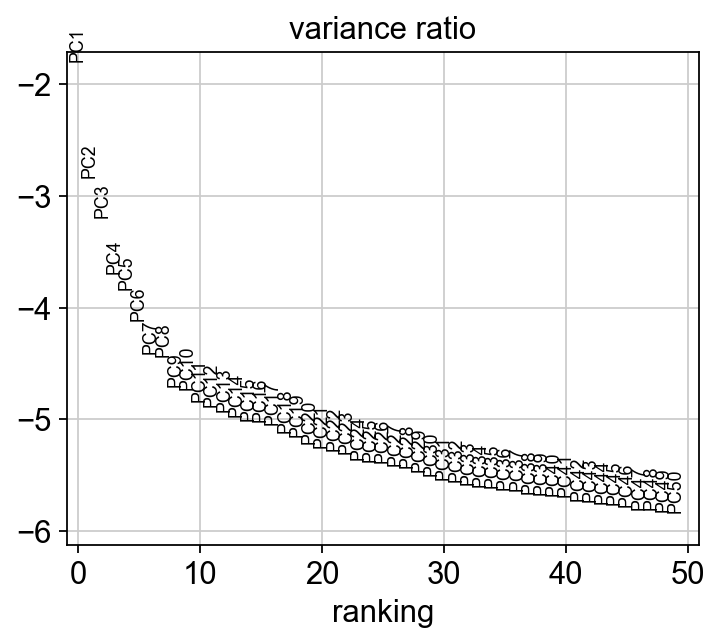

In [94]:
# ============================================
# PCA on RNA data
# - run PCA on selected genes (HVGs)
# - prepare for neighbors / UMAP
# ============================================

from multiomic_vae.data.preprocess_rna import run_pca

adata_rna = run_pca(adata_rna, n_comps=50)
sc.pl.pca_variance_ratio(adata_rna, n_pcs=50, log=True)

### 1.7) UMAP and Leidens
NOTE: Clustering results shown at this stage are for exploratory purposes only and are not used for model training or final evaluation.

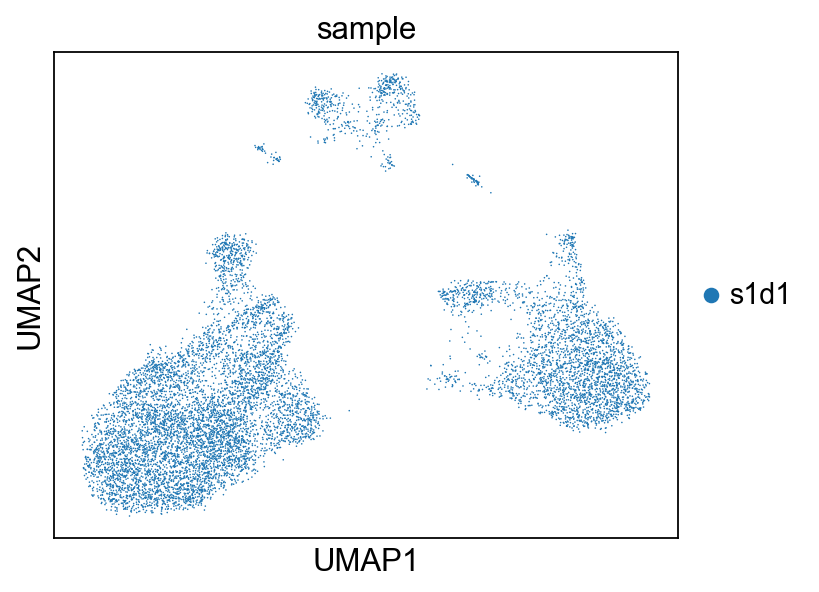

In [95]:
# ============================================
# Neighbors graph + UMAP
# ============================================

from multiomic_vae.data.preprocess_rna import run_neighbors_umap

adata_rna = run_neighbors_umap(
    adata_rna,
    n_neighbors=15,
    n_pcs=50
)

sc.pl.umap(adata_rna, color="sample", size=2)

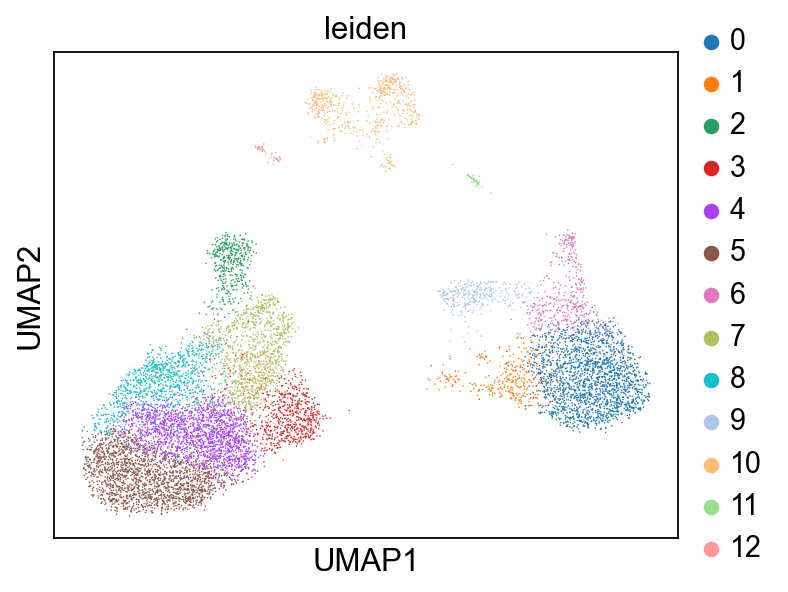

In [96]:
# ============================================
# Leiden clustering
# ============================================

from multiomic_vae.data.preprocess_rna import run_leiden

adata_rna = run_leiden(adata_rna)
sc.pl.umap(adata_rna, color="leiden", size=2)

### 1.8) Convert to Cell*Gene preprocessed to Dataframe

In [97]:
# ===============================
# Convert AnnData to cell × gene DataFrame
# ===============================

df_rna = pd.DataFrame(
    adata_rna.X.toarray(),
    index=adata_rna.obs_names,   # cell identifiers
    columns=adata_rna.var_names  # gene identifiers
)

print(df_rna.shape)
df_rna.head()

(10150, 25545)


,AL627309.1,AL627309.5,AL627309.4,LINC01409,FAM87B,LINC01128,LINC00115,FAM41C,AL645608.6,SAMD11,...,MT-CYB,BX004987.1,AC145212.1,MAFIP,AC011043.1,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC007325.4
AAACAGCCAACAACAA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.781009,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
AAACAGCCACCGGCTA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.848636,0.0,0.0,0.0,0.0,0.0,0.0,0.734424,0.0,0.0
AAACAGCCAGGACACA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.434827,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
AAACAGCCATCCTAGA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.215630,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
AAACATGCAAAGGTAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.949238,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


# 2) Preprocessing Cell * Peak

In [98]:
# ===============================
# Load cell × peak matrix from 10x multiome file
# Extract peaks modality as sparse DataFrame
# ===============================

from multiomic_vae.data.preprocessing_peak import load_cell_peak_df

peak_path = DATA_DIR / "pbmc_10k" / "10k_PBMC_Multiome_nextgem_Chromium_X_filtered_feature_bc_matrix.h5"

cell_peak_df = load_cell_peak_df(peak_path)

print(cell_peak_df.shape)
cell_peak_df.head()

C:\Users\user\anaconda3\envs\peakvi\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(10970, 111743)


,chr1:9775-10665,chr1:180675-181178,chr1:181244-181699,chr1:191110-192051,chr1:267575-268460,chr1:270861-271740,chr1:585752-586648,chr1:629395-630394,chr1:633578-634591,chr1:778283-779200,...,KI270726.1:41483-42332,KI270711.1:7942-8758,KI270711.1:9020-9586,KI270713.1:3955-4859,KI270713.1:21453-22374,KI270713.1:25837-26623,KI270713.1:29669-30477,KI270713.1:32767-33478,KI270713.1:34197-35025,KI270713.1:36904-37809
AAACAGCCAACAACAA-1,2.0,0,0,0,0,0,0,0,0,2.0,...,0,0,0,0,0,0,0,0,0,0
AAACAGCCACCGGCTA-1,0,0,0,0,0,0,0,0,2.0,4.0,...,0,0,0,0,0,0,0,0,0,0
AAACAGCCAGGACACA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACAGCCATCCTAGA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,4.0,0,0,0,0,0
AAACATGCAAAGGTAC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [99]:
# ===============================
# Filtering to keep only chromosomes 1-22, X, and Y
# ===============================

from multiomic_vae.data.preprocessing_peak import filter_valid_chromosomes_df

cell_peak_df = filter_valid_chromosomes_df(cell_peak_df)
print(cell_peak_df.shape)

(10970, 111680)


In [100]:
# ===============================
# Compute peak activity across cells
# peak_counts: number of cells where each peak is active
# peak_frac: fraction of cells in which each peak is accessible
# ===============================

from multiomic_vae.data.preprocessing_peak import compute_peak_activity

peak_counts, peak_frac = compute_peak_activity(cell_peak_df)

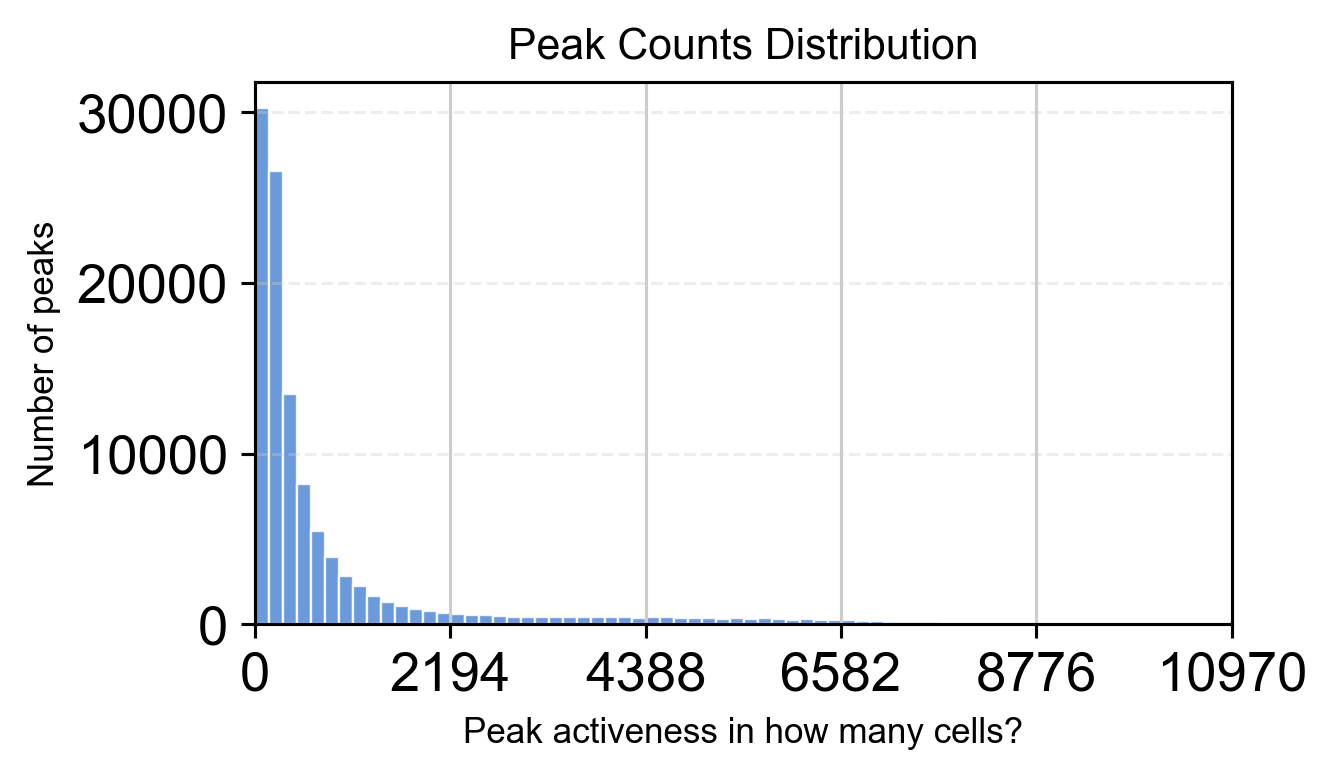

In [101]:
# ===============================
# Visualize peak activity distribution
# Shows how many cells each peak is active in
# ===============================

from multiomic_vae.data.preprocessing_peak import plot_peak_activity

n_cells = cell_peak_df.shape[0]
plot_peak_activity(peak_counts, n_cells)


In [102]:
# ===============================
# Peak retention under different activity thresholds
# Shows how many peaks remain if we require minimum activity across cells
# ===============================

from multiomic_vae.data.preprocessing_peak import print_peak_threshold_summary

print_peak_threshold_summary(peak_frac)

Peaks active in ≥1% of cells: 95520
Peaks active in ≥2% of cells: 68742
Peaks active in ≥3% of cells: 53433
Peaks active in ≥4% of cells: 43788
Peaks active in ≥5% of cells: 36987


In [103]:
# ===============================
# Filter peaks based on activity fraction
# Retain peaks active in at least 3% of cells
# ===============================

from multiomic_vae.data.preprocessing_peak import filter_peaks_by_fraction

cell_peak_df_filtered, peak_mask = filter_peaks_by_fraction(
    cell_peak_df,
    peak_frac,
    min_frac=0.04
)

cell_peak_df_filtered.shape

(10970, 43788)

In [104]:
# ===============================
# Compute sparsity of cell × peak matrix
# Measures fraction of zero entries in the matrix
# ===============================

from multiomic_vae.data.preprocessing_peak import compute_sparsity

sparsity_before = compute_sparsity(cell_peak_df)
sparsity_after = compute_sparsity(cell_peak_df_filtered)

sparsity_before, sparsity_after

(np.float64(0.9202516321538554), np.float64(0.8243724049886838))

In [105]:
# ===============================
# Apply log(1 + x) transformation to peak matrix
# Stabilizes variance before model training
# ===============================

from multiomic_vae.data.preprocessing_peak import log1p_peak_matrix

cell_peak_df_log = log1p_peak_matrix(cell_peak_df_filtered)

# 4) Harmonization of Cell * Gene - Cell * Peak matrices

In [106]:
# ===============================
# Align cells between RNA and peak modalities
# Retain only cells present in both matrices
# ===============================


from multiomic_vae.data.harmonization import align_cells_between_modalities

cell_peak_df_aligned, df_rna_aligned = align_cells_between_modalities(
    cell_peak_df_log,
    df_rna
)

cell_peak_df_aligned.shape, df_rna_aligned.shape

((10150, 43788), (10150, 25545))

# 5) Saving Preprocessed data

In [108]:
# ===============================
# Save preprocessed cell × peak matrix
# ===============================

from multiomic_vae.utils.io_utils import save_sparse_matrix

save_sparse_matrix(
    cell_peak_df_aligned,
    PROCESSED_DATA_DIR / "pbmc_10k" / "cell_peak_preprocessed.npz"
)

In [109]:
# ===============================
# Save preprocessed cell × peak matrix
# ===============================

from multiomic_vae.utils.io_utils import save_sparse_matrix

save_sparse_matrix(
    df_rna_aligned,
    PROCESSED_DATA_DIR / "pbmc_10k" / "cell_gene_preprocessed.npz"
)

In [110]:
# ===============================
# Create and save aligned RNA Leiden cluster labels
# Subset original clustering to shared cells and store for evaluation
# ===============================

import os

leiden_aligned = pd.DataFrame({
    "cell_id": df_rna_aligned.index,
    "leiden": adata_rna.obs.loc[df_rna_aligned.index, "leiden"].astype(str)
})

output_dir = PROCESSED_DATA_DIR / "pbmc_10k"
os.makedirs(output_dir, exist_ok=True)

leiden_aligned.to_csv(
    output_dir / "rna_leiden_labels.csv",
    index=False
)

leiden_aligned.head()

,cell_id,leiden
AAACAGCCAACAACAA-1,AAACAGCCAACAACAA-1,0
AAACAGCCACCGGCTA-1,AAACAGCCACCGGCTA-1,2
AAACAGCCAGGACACA-1,AAACAGCCAGGACACA-1,3
AAACAGCCATCCTAGA-1,AAACAGCCATCCTAGA-1,0
AAACATGCAAAGGTAC-1,AAACATGCAAAGGTAC-1,0
